<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Qubit_Decoherence_Based_on_7_Classifications_Illustrative_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [12]:
!uv pip install qutip matplotlib

Using Python 3.12.13 environment at: /usr
Checked 2 packages in 88ms


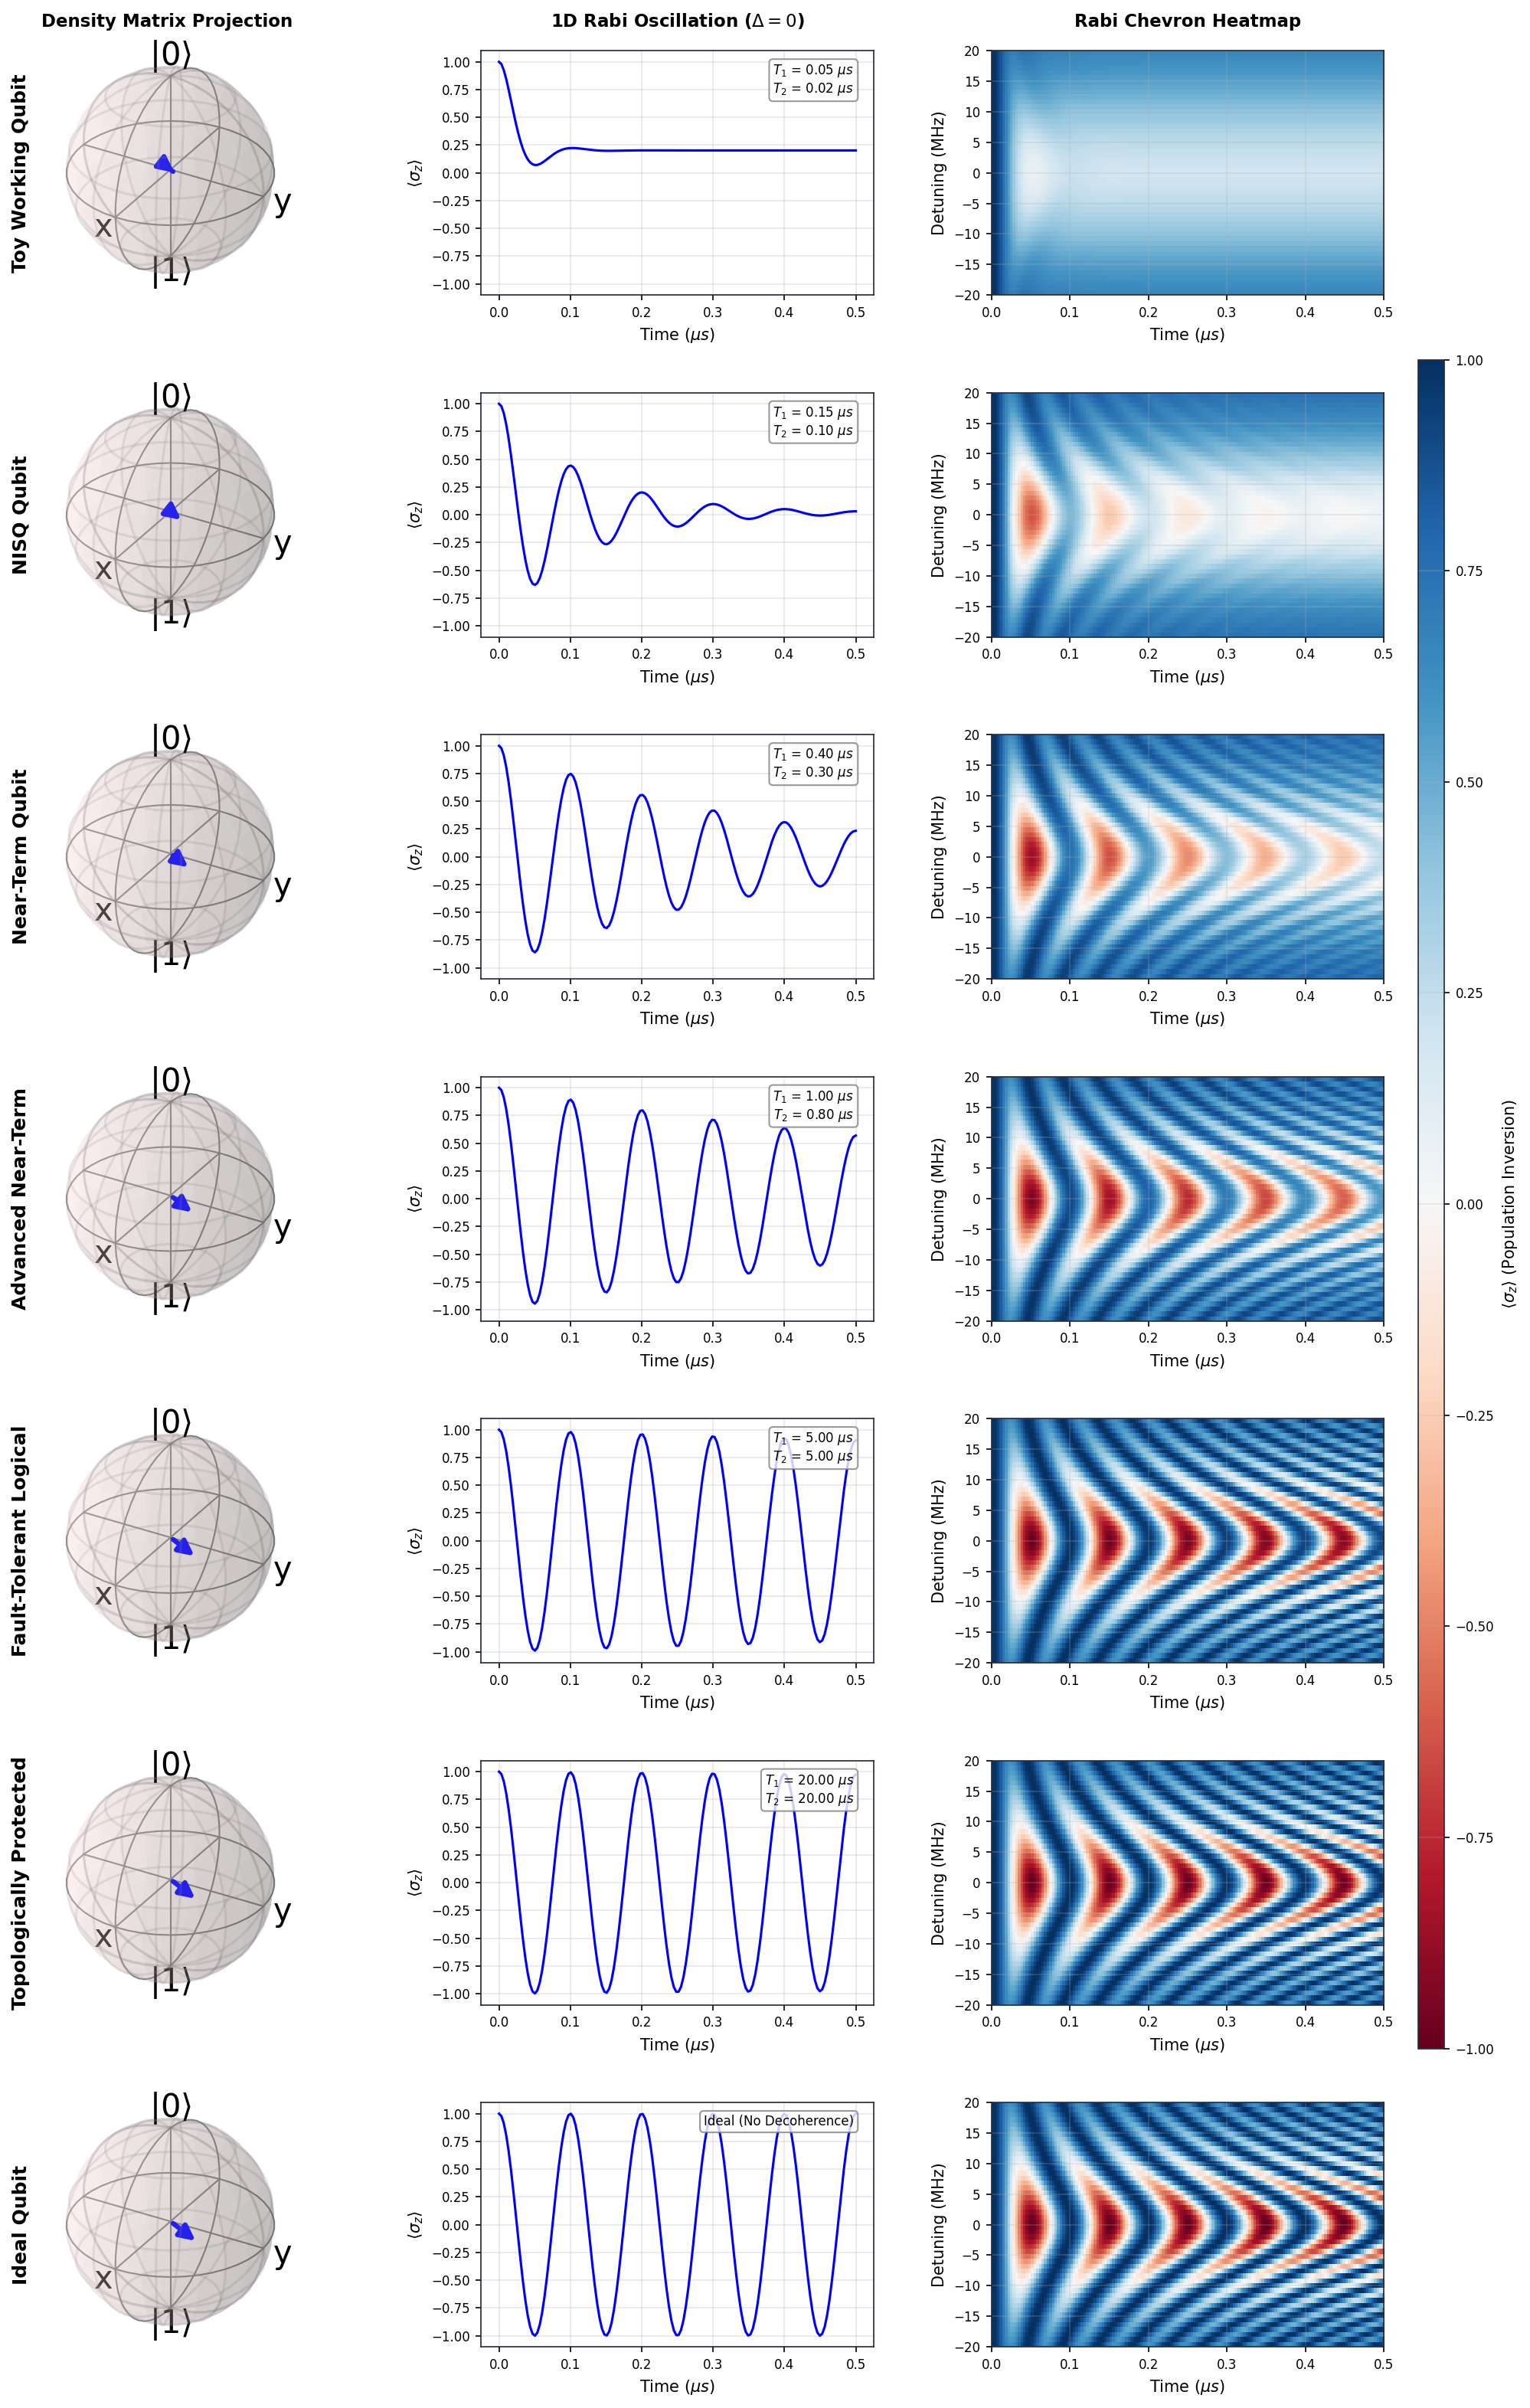

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import Bloch, Qobj, identity, sigmax, sigmay, sigmaz, basis, mesolve, expect, destroy

"""
This script simulates and visualizes density matrices, 1D Rabi oscillations,
and 2D Rabi heatmaps (Chevron plots) for seven distinct qubit classifications using QuTiP.
Fully labeled with axes, parameters, and Bloch sphere poles.
"""

# ==============================================================================
# CONTROL KNOBS & GLOBAL SETTINGS
# ==============================================================================
TARGET_THETA = np.pi / 2.5
TARGET_PHI = np.pi / 4.0
COLOR_PURE_BLUE = '#0000FF'
PLOT_DPI = 150
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']

# Physics Simulation Parameters
OMEGA = 2.0 * np.pi * 10.0       # Drive frequency (10 MHz)
TIME_STEPS = 150
TIME_MAX = 0.5                   # Maximum simulation time in microseconds
T_LIST = np.linspace(0, TIME_MAX, TIME_STEPS)

# Detuning parameters for the Heatmap (Chevron plot)
DETUNING_STEPS = 50
DETUNING_MAX = 2.0 * np.pi * 20.0
DETUNING_LIST = np.linspace(-DETUNING_MAX, DETUNING_MAX, DETUNING_STEPS)

# Decoherence Profiles for each classification (T1, T2 in microseconds)
CLASSIFICATIONS = [
    {"name": "Toy Working Qubit",       "radius": 0.15, "T1": 0.05,  "T2": 0.02},
    {"name": "NISQ Qubit",              "radius": 0.50, "T1": 0.15,  "T2": 0.10},
    {"name": "Near-Term Qubit",         "radius": 0.75, "T1": 0.40,  "T2": 0.30},
    {"name": "Advanced Near-Term",      "radius": 0.88, "T1": 1.00,  "T2": 0.80},
    {"name": "Fault-Tolerant Logical",  "radius": 0.96, "T1": 5.00,  "T2": 5.00},
    {"name": "Topologically Protected", "radius": 0.99, "T1": 20.0,  "T2": 20.0},
    {"name": "Ideal Qubit",             "radius": 1.00, "T1": np.inf,"T2": np.inf}
]

# ==============================================================================
# ENVIRONMENT CONFIGURATION
# ==============================================================================
mpl.rcParams['figure.dpi'] = PLOT_DPI
mpl.rcParams['font.sans-serif'] = FONT_SANS_SERIF
mpl.rcParams['savefig.dpi'] = PLOT_DPI
mpl.rcParams['font.size'] = 8

# ==============================================================================
# PHYSICS SIMULATION FUNCTIONS
# ==============================================================================
def get_collapse_operators(t1: float, t2: float) -> list:
    """Constructs the Lindblad collapse operators based on T1 and T2 times.

    Args:
        t1: The longitudinal relaxation time (T1) in microseconds.
        t2: The transverse relaxation time (T2) in microseconds.

    Returns:
        A list of QuTiP quantum objects representing the collapse operators.
    """
    c_ops = []
    sm = destroy(2)
    sz = sigmaz()

    if not np.isinf(t1):
        gamma1 = 1.0 / t1
        c_ops.append(np.sqrt(gamma1) * sm)

    if not np.isinf(t2):
        gamma1 = 0.0 if np.isinf(t1) else 1.0 / t1
        gamma2 = 1.0 / t2
        gamma_phi = gamma2 - (gamma1 / 2.0)

        if gamma_phi > 0:
            c_ops.append(np.sqrt(gamma_phi / 2.0) * sz)

    return c_ops

def simulate_rabi_dynamics(t1: float, t2: float, detuning: float) -> np.ndarray:
    """Solves the master equation for a driven qubit and returns sz expectation.

    Args:
        t1: Longitudinal relaxation time (T1) in microseconds.
        t2: Transverse relaxation time (T2) in microseconds.
        detuning: Detuning frequency Delta between drive and qubit.

    Returns:
        A NumPy array containing the expectation value of the sigma_z operator.
    """
    H = (detuning / 2.0) * sigmaz() + (OMEGA / 2.0) * sigmax()
    psi0 = basis(2, 0)
    c_ops = get_collapse_operators(t1, t2)
    result = mesolve(H, psi0, T_LIST, c_ops=c_ops, e_ops=[sigmaz()])
    return result.expect[0]

def generate_chevron_data(t1: float, t2: float) -> np.ndarray:
    """Generates the 2D data array for the Rabi heatmap across detunings.

    Args:
        t1: Longitudinal relaxation time (T1) in microseconds.
        t2: Transverse relaxation time (T2) in microseconds.

    Returns:
        A 2D NumPy array representing the Chevron plot data.
    """
    heatmap_data = np.zeros((DETUNING_STEPS, TIME_STEPS))
    for i, delta in enumerate(DETUNING_LIST):
        heatmap_data[i, :] = simulate_rabi_dynamics(t1, t2, delta)
    return heatmap_data

def generate_bloch_vector(theta: float, phi: float, radius: float) -> list:
    """Calculates Cartesian coordinates for a Bloch vector.

    Args:
        theta: Polar angle in radians.
        phi: Azimuthal angle in radians.
        radius: The length of the Bloch vector (purity).

    Returns:
        A list containing the [x, y, z] Cartesian coordinates.
    """
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return [x, y, z]

# ==============================================================================
# VISUALIZATION EXECUTION
# ==============================================================================
def main():
    """Main execution block mapping the data to a comprehensive subplot grid."""
    num_classes = len(CLASSIFICATIONS)
    fig = plt.figure(figsize=(15, 3.0 * num_classes))

    for row, cls in enumerate(CLASSIFICATIONS):
        name = cls["name"]
        t1 = cls["T1"]
        t2 = cls["T2"]
        radius = cls["radius"]

        # -----------------------------------------------------------
        # Column 1: Static Density Matrix on Bloch Sphere
        # -----------------------------------------------------------
        ax1 = fig.add_subplot(num_classes, 3, (row * 3) + 1, projection='3d')
        vec = generate_bloch_vector(TARGET_THETA, TARGET_PHI, radius)
        rho_state = 0.5 * (identity(2) + vec[0]*sigmax() + vec[1]*sigmay() + vec[2]*sigmaz())

        bloch_sphere = Bloch(fig=fig, axes=ax1)
        bloch_sphere.vector_color = [COLOR_PURE_BLUE]
        bloch_sphere.add_states(rho_state)

        # Explicitly label the Bloch sphere axes and poles
        bloch_sphere.xlabel = ['x', '']
        bloch_sphere.ylabel = ['y', '']
        bloch_sphere.zlabel = [r'$|0\rangle$', r'$|1\rangle$']
        bloch_sphere.render()

        if row == 0:
            ax1.set_title("Density Matrix Projection", pad=15, fontsize=11, weight='bold')

        # Row label
        ax1.text2D(-0.1, 0.5, name, transform=ax1.transAxes,
                   rotation=90, va='center', ha='center', fontsize=12, weight='bold')

        # -----------------------------------------------------------
        # Column 2: 1D Time-Domain Rabi Oscillation
        # -----------------------------------------------------------
        ax2 = fig.add_subplot(num_classes, 3, (row * 3) + 2)
        sz_trace = simulate_rabi_dynamics(t1, t2, detuning=0.0)

        ax2.plot(T_LIST, sz_trace, color=COLOR_PURE_BLUE, linewidth=1.5)
        ax2.set_ylim(-1.1, 1.1)
        ax2.set_ylabel(r'$\langle \sigma_z \rangle$')
        ax2.set_xlabel(r'Time ($\mu s$)')
        ax2.grid(True, alpha=0.3)

        # Add parameter labels inside the plot
        if np.isinf(t1):
            param_text = "Ideal (No Decoherence)"
        else:
            param_text = f"$T_1$ = {t1:.2f} $\\mu s$\n$T_2$ = {t2:.2f} $\\mu s$"

        ax2.text(0.95, 0.95, param_text, transform=ax2.transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

        if row == 0:
            ax2.set_title(r"1D Rabi Oscillation ($\Delta = 0$)", pad=15, fontsize=11, weight='bold')

        # -----------------------------------------------------------
        # Column 3: 2D Rabi Heatmap (Chevron Plot)
        # -----------------------------------------------------------
        ax3 = fig.add_subplot(num_classes, 3, (row * 3) + 3)
        heatmap_data = generate_chevron_data(t1, t2)

        extent = [0, TIME_MAX, -DETUNING_MAX/(2*np.pi), DETUNING_MAX/(2*np.pi)]
        im = ax3.imshow(heatmap_data, aspect='auto', origin='lower',
                        extent=extent, cmap='RdBu', vmin=-1.0, vmax=1.0)

        ax3.set_ylabel(r'Detuning (MHz)')
        ax3.set_xlabel(r'Time ($\mu s$)')

        if row == 0:
            ax3.set_title("Rabi Chevron Heatmap", pad=15, fontsize=11, weight='bold')

    plt.tight_layout()
    plt.subplots_adjust(left=0.08, right=0.9, wspace=0.3, hspace=0.4)

    # Unified colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label=r'$\langle \sigma_z \rangle$ (Population Inversion)')

    plt.show()

if __name__ == '__main__':
    main()

Simulating 1/7: Toy working qubit
Simulating 2/7: Noisy intermediate-scale qubit
Simulating 3/7: Near-term qubit
Simulating 4/7: Advanced near-term qubit
Simulating 5/7: Fault-tolerant logical qubit
Simulating 6/7: Topologically protected qubit
Simulating 7/7: Ideal qubit


,Regime,Target p,Observed p_hat,Wilson low,Wilson high,Simulated P1(t_pi),T1 (us),T2 (us),Bias (MHz),Drive scale,Purity,l1 coherence,Bloch radius,Minimum eigenvalue
0,Toy working qubit,0.500000,0.502500,0.492701,0.512297,0.500000,0.050,0.020,1.800000,1.206681,0.516828,0.183457,0.183457,0.408272
1,Noisy intermediate-scale qubit,0.600000,0.601000,0.591365,0.610557,0.600000,0.150,0.100,1.300000,0.687667,0.795804,0.742703,0.769160,0.115420
2,Near-term qubit,0.700000,0.700800,0.691749,0.709696,0.700000,0.400,0.300,0.900000,0.681224,0.912588,0.815583,0.908392,0.045804
3,Advanced near-term qubit,0.800000,0.800600,0.792654,0.808315,0.800000,1.000,0.800,0.400000,0.728049,0.961100,0.749800,0.960312,0.019844
4,Fault-tolerant logical qubit,0.900000,0.901300,0.895299,0.906993,0.900000,5.000,5.000,0.100000,0.800840,0.992404,0.587204,0.992375,0.003812
5,Topologically protected qubit,0.980000,0.979700,0.976746,0.982285,0.980000,20.000,20.000,0.020000,0.912726,0.997742,0.271815,0.997739,0.001130
6,Ideal qubit,1.000000,1.000000,0.999616,1.000000,1.000000,∞,∞,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000


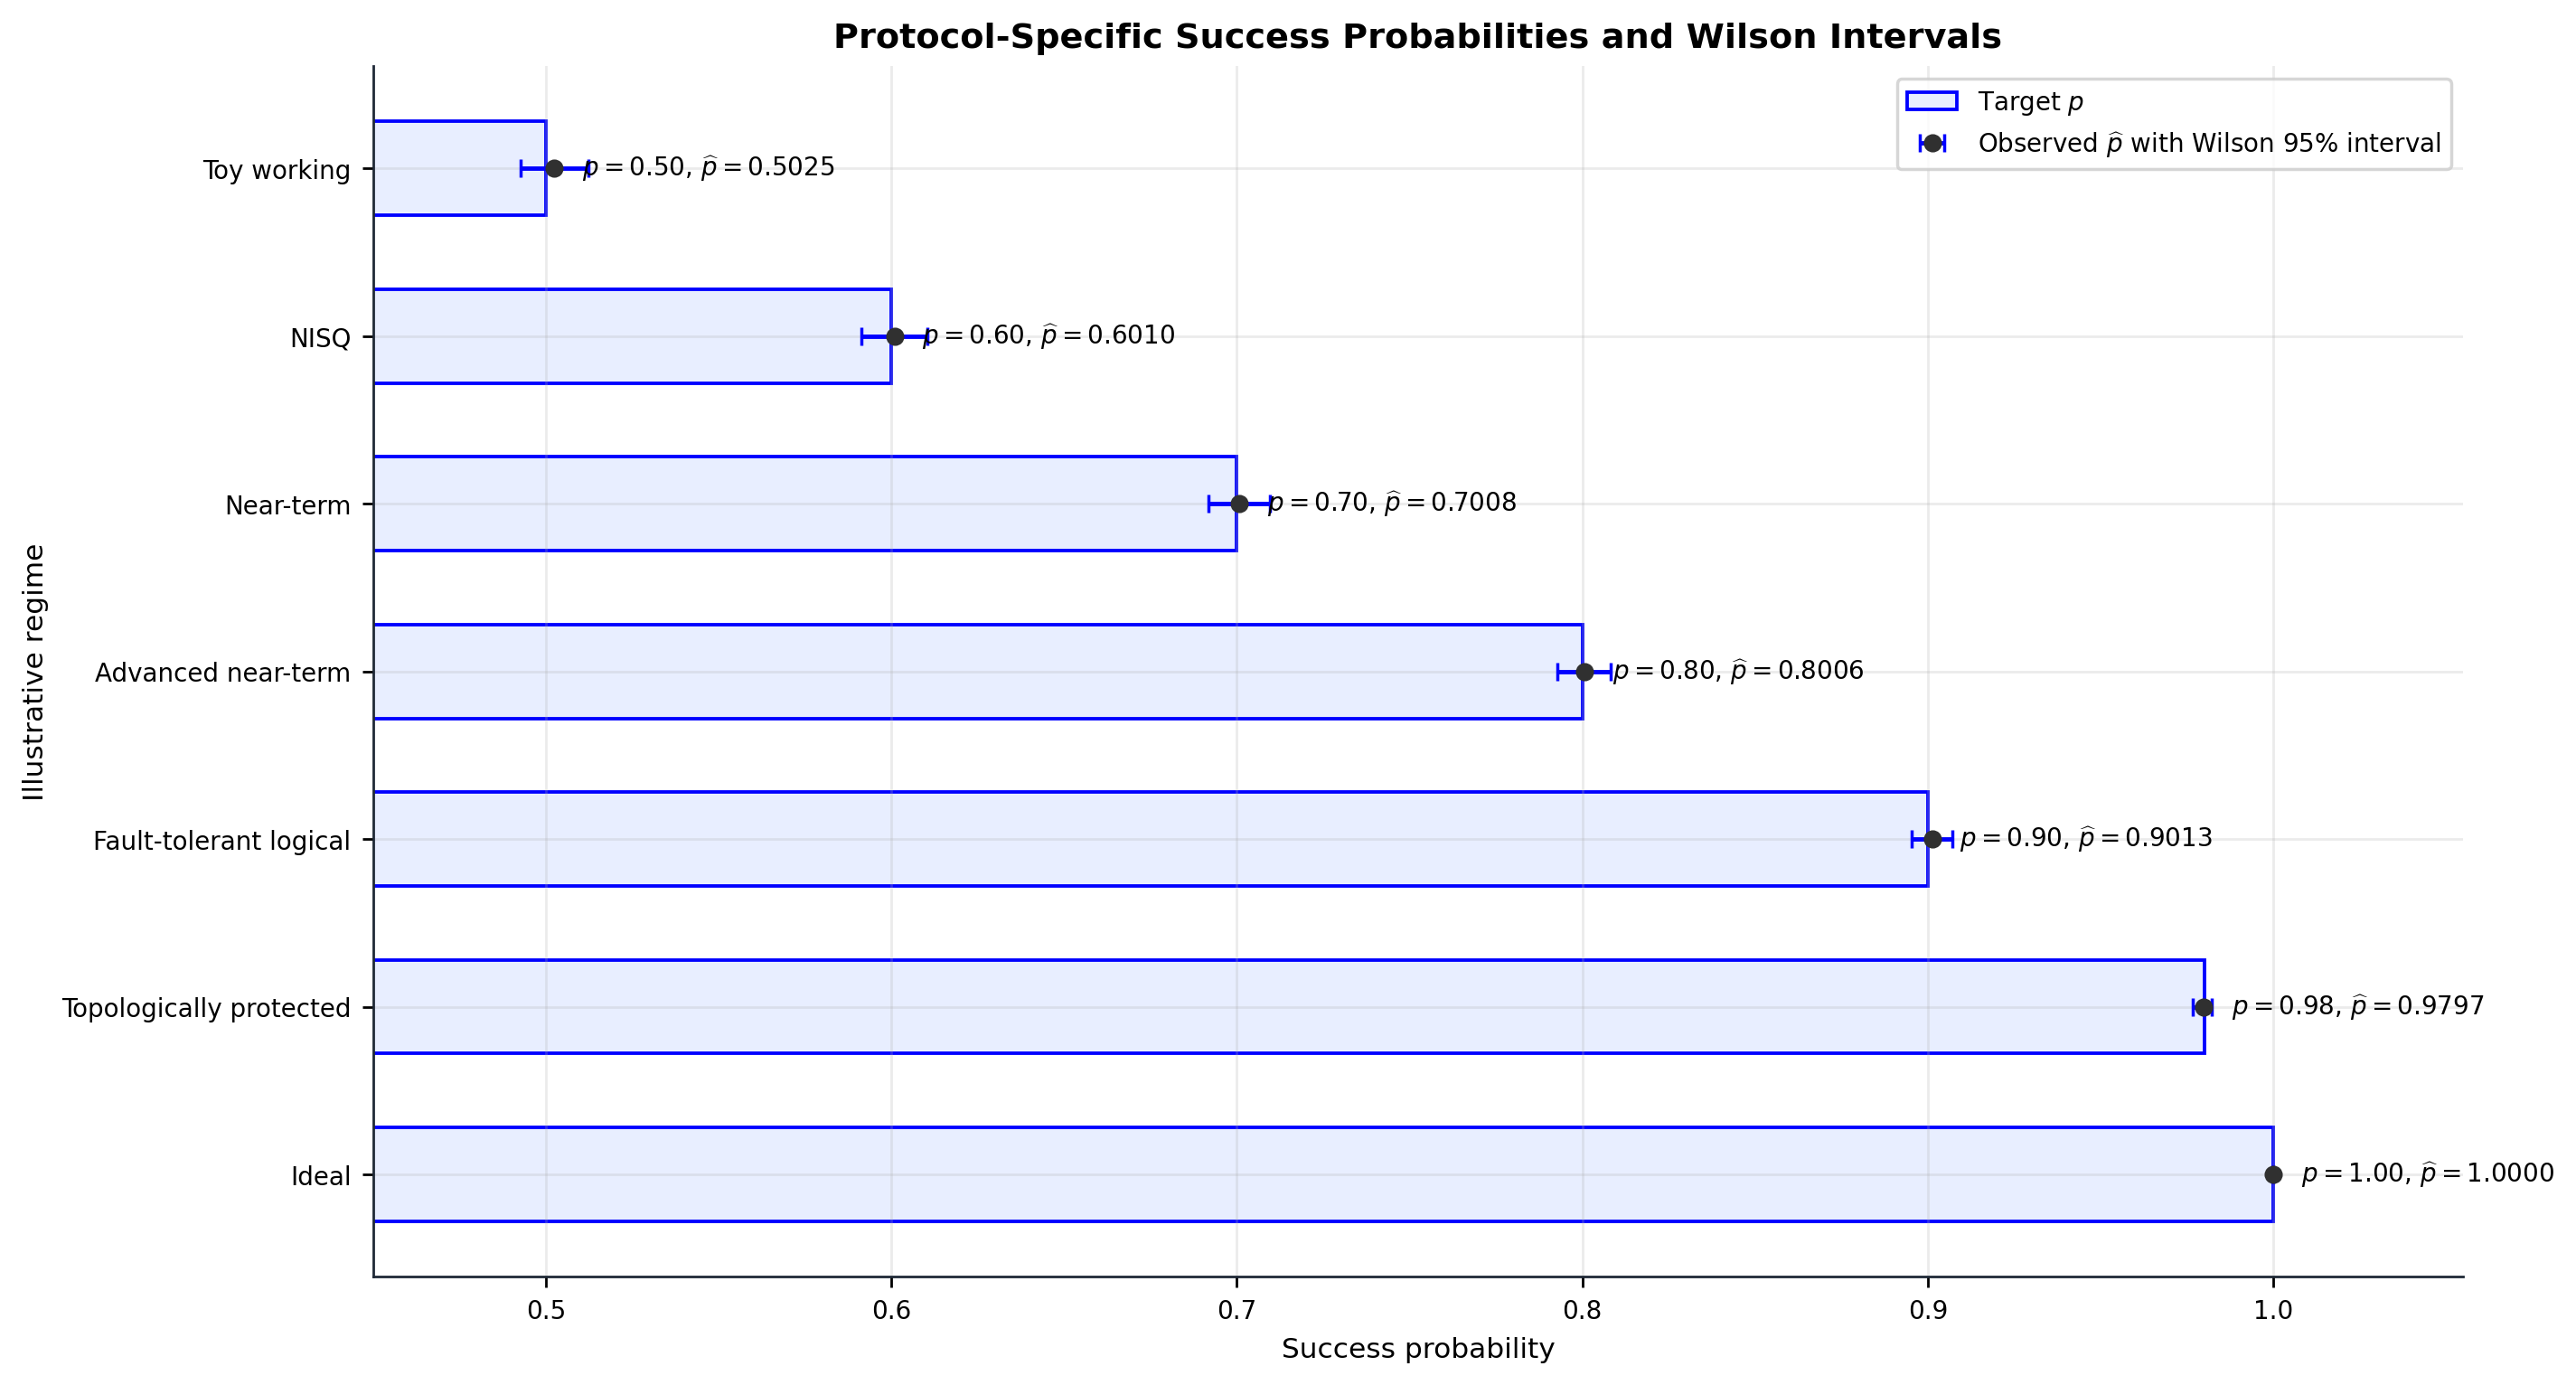

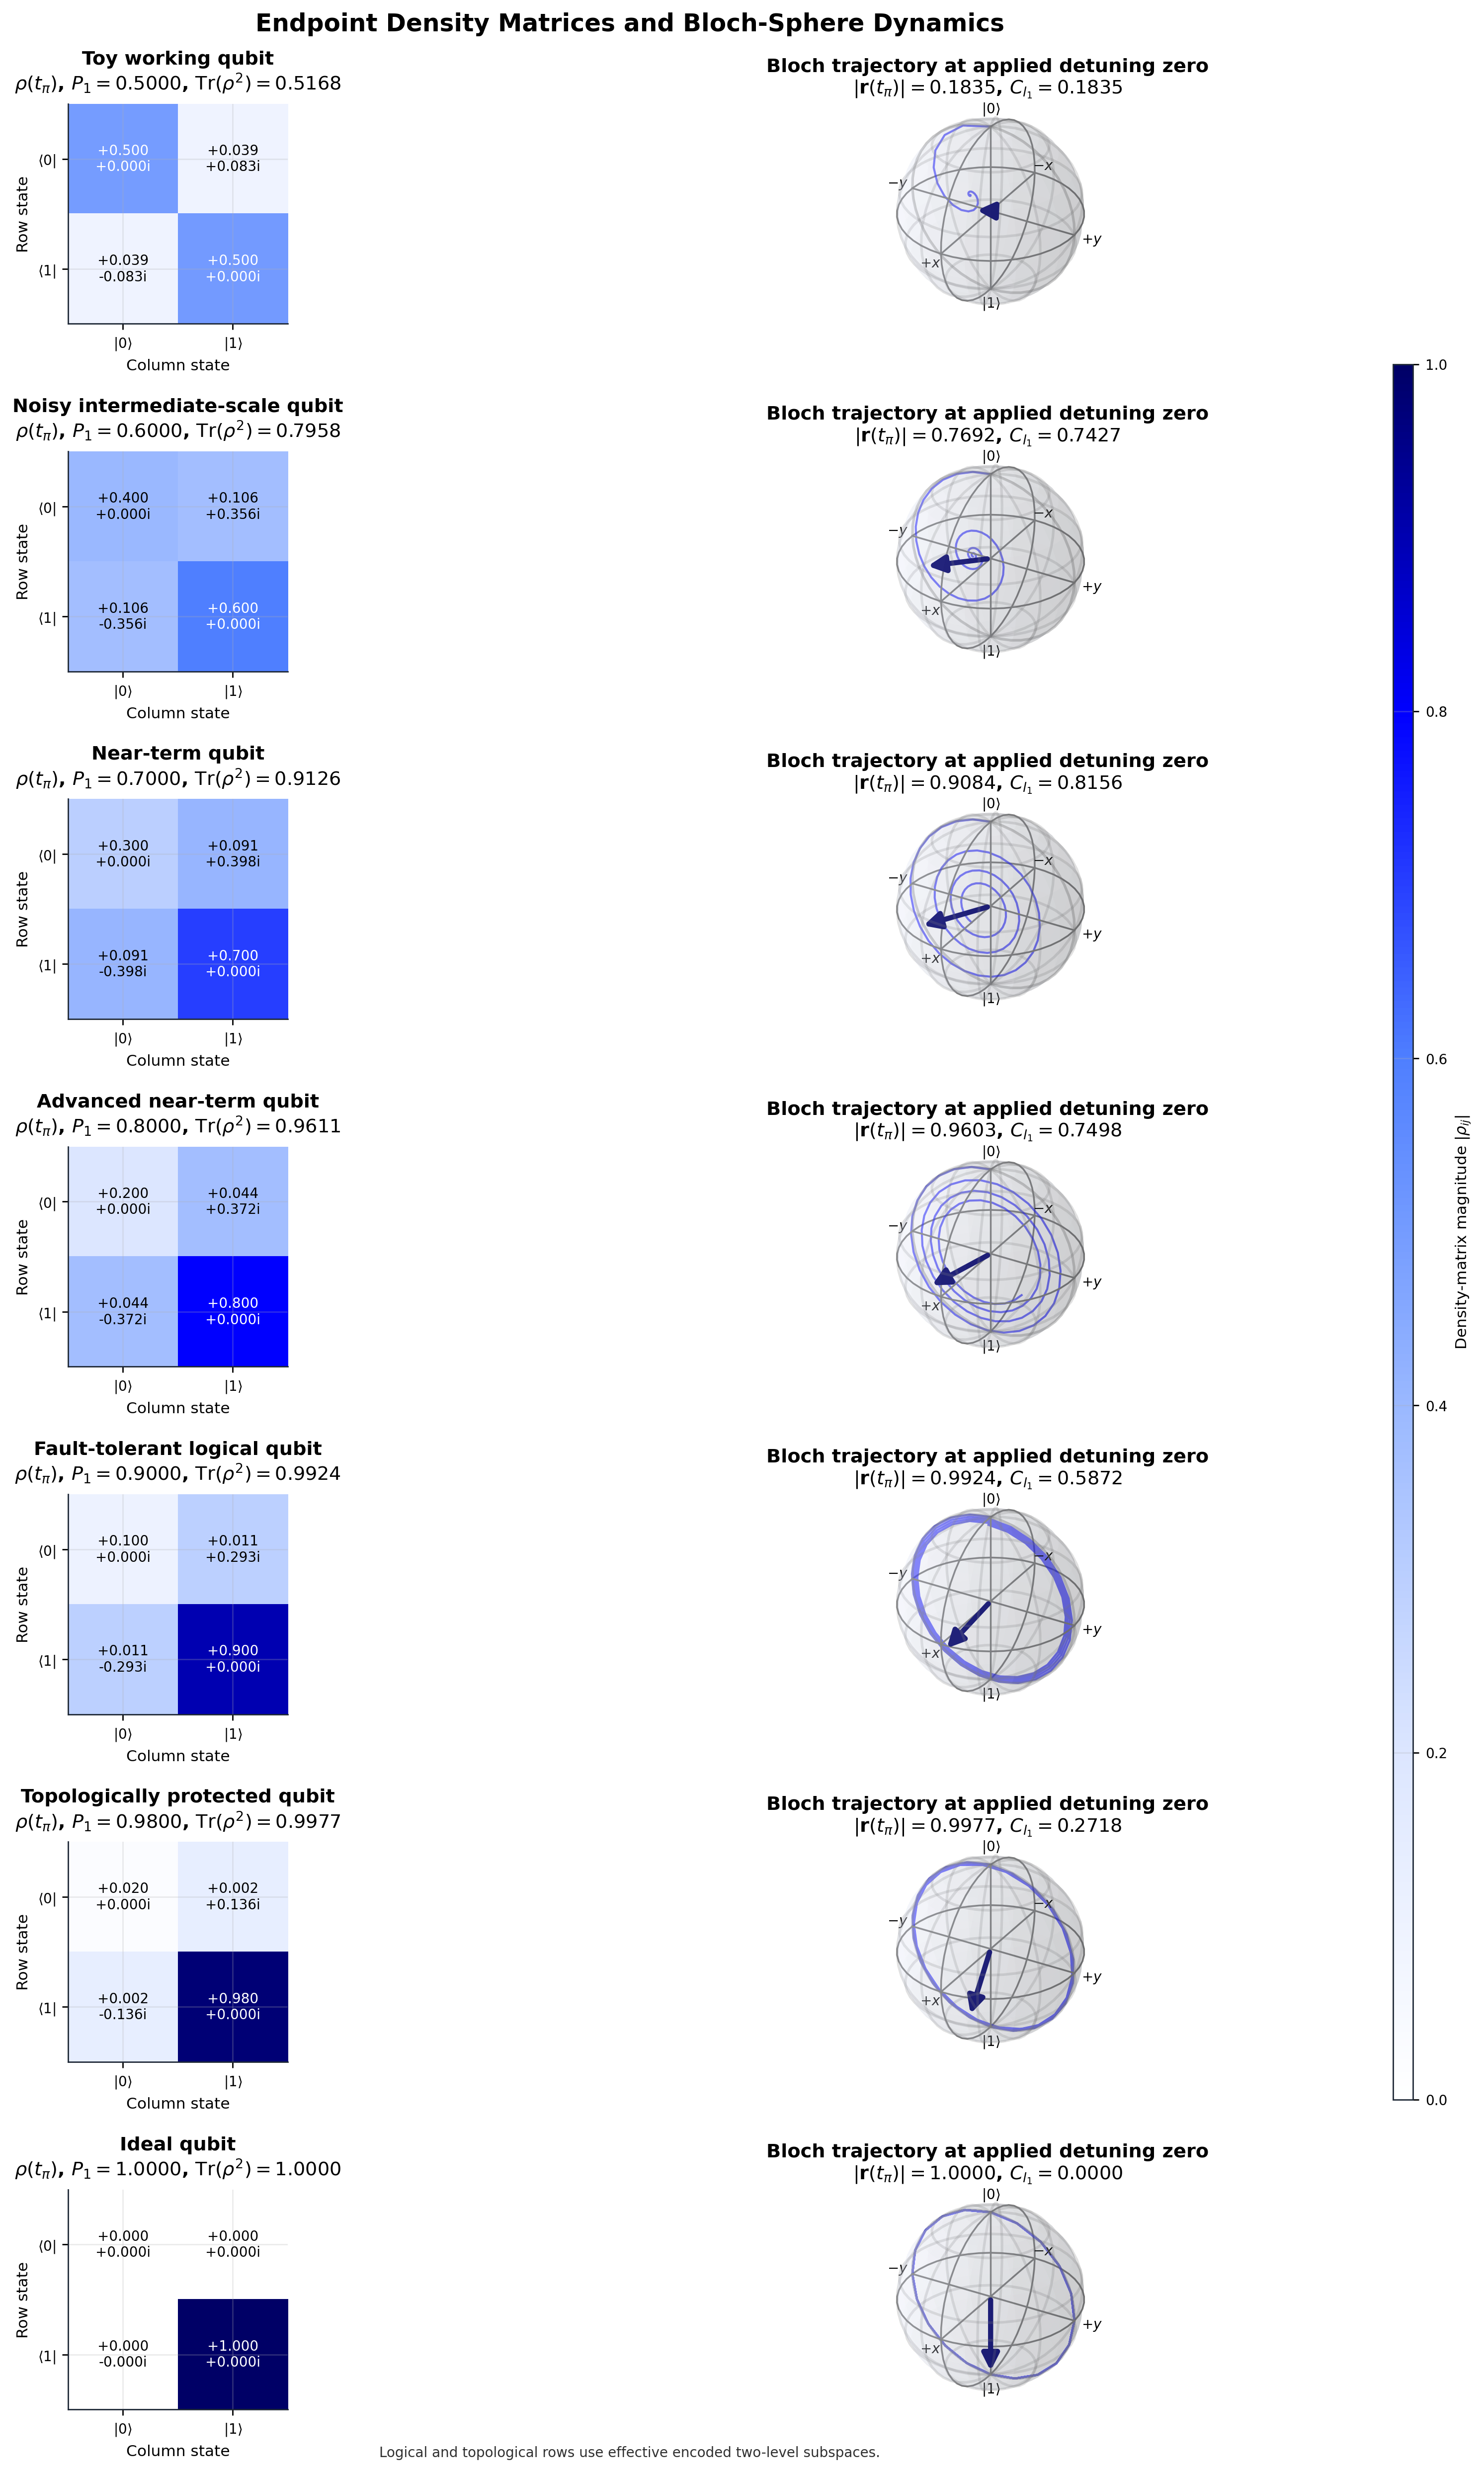

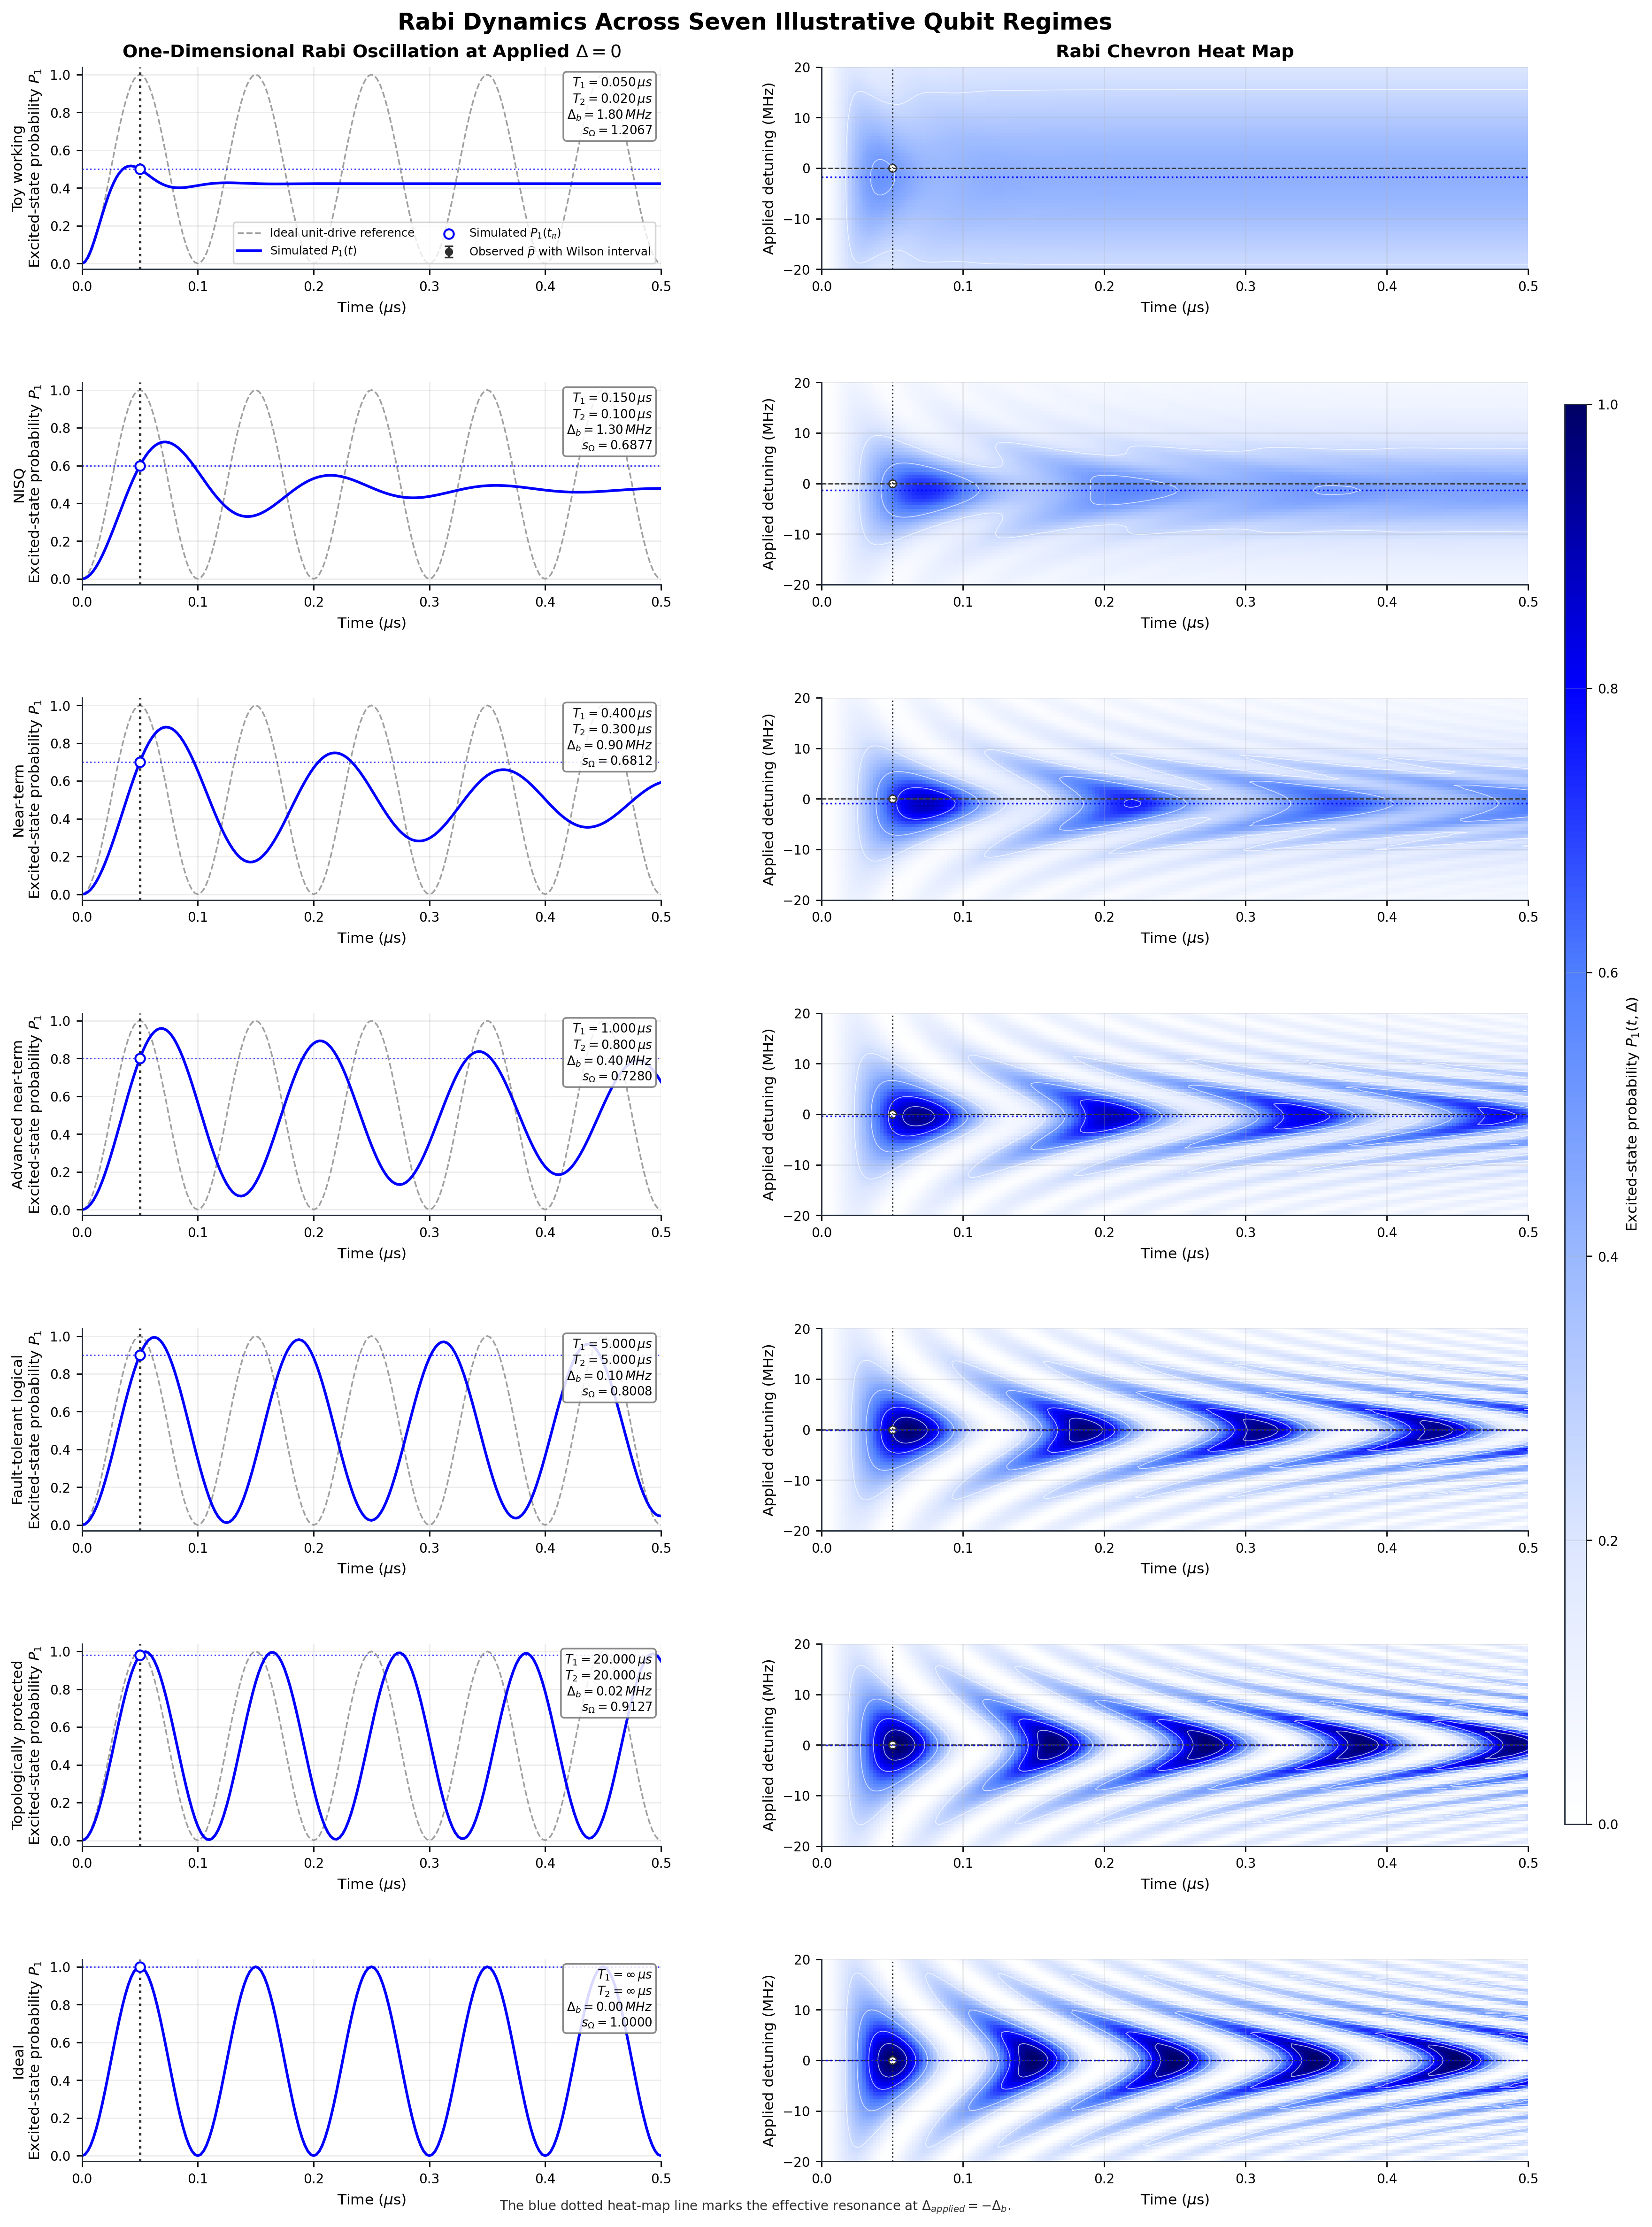

In [16]:
"""Plot seven illustrative qubit regimes with QuTiP.

The declared success event is defined by one explicit protocol: prepare |0>,
apply a nominal pi pulse, and measure |1>.  Under this protocol,

    p = Tr[|1><1| rho(t_pi)].

The supplied labels and binomial counts form a pedagogical ladder.  A scalar p
alone leaves the state and channel underdetermined, so the effective T1, T2,
detuning bias, and drive scale below are visualization parameters.  Logical
and topological rows are represented as effective encoded two-level subspaces.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qutip as qt
from matplotlib.axes import Axes
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.figure import Figure
from scipy.optimize import brentq, minimize_scalar


# =============================================================================
# CONTROL KNOBS
# =============================================================================
PLOT_DPI = 250
FONT_SANS_SERIF = ["IBM Plex Sans", "Tahoma", "DejaVu Sans"]
PURE_BLUE = "#0000FF"
DARK_BLUE = "#000066"
LIGHT_BLUE = "#E8EEFF"
CHARCOAL = "#303030"
GRAY = "#777777"

BASE_RABI_FREQUENCY_MHZ = 10.0
TIME_MAX_US = 0.50
TIME_POINT_COUNT = 201
DETUNING_LIMIT_MHZ = 20.0
DETUNING_POINT_COUNT = 61

AUTO_CALIBRATE_DRIVE_SCALE = True
DRIVE_SCALE_MAX = 1.60
CALIBRATION_TOLERANCE = 1.0e-8

SOLVER_METHOD = "dop853"
SOLVER_ATOL = 1.0e-10
SOLVER_RTOL = 1.0e-8
SOLVER_NSTEPS = 10_000

SHOW_SUCCESS_FIGURE = True
SHOW_STATE_FIGURE = True
SHOW_RABI_FIGURE = True
DISPLAY_SUMMARY_TABLE = True
SAVE_FIGURES = False
OUTPUT_DIRECTORY = Path("qutip_qubit_comparison_outputs")

WILSON_Z_95 = 1.959963984540054


@dataclass(frozen=True)
class Regime:
    """Contains statistical data and an effective two-level model."""

    name: str
    short_name: str
    target_p: float
    shots: int
    successes: int
    t1_us: float
    t2_us: float
    detuning_bias_mhz: float
    drive_scale_seed: float

    @property
    def observed_p(self) -> float:
        """Return the observed success fraction."""
        return self.successes / self.shots


@dataclass(frozen=True)
class Simulation:
    """Contains the numerical products for one regime."""

    regime: Regime
    drive_scale: float
    p1: np.ndarray
    sx: np.ndarray
    sy: np.ndarray
    sz: np.ndarray
    rho_pi: qt.Qobj
    chevron: np.ndarray
    purity: float
    l1_coherence: float
    bloch_radius: float
    minimum_eigenvalue: float

    @property
    def simulated_p(self) -> float:
        """Return the success probability at the nominal pi pulse."""
        return float(np.real(qt.expect(P_ONE, self.rho_pi)))


REGIMES = (
    Regime(
        "Toy working qubit",
        "Toy working",
        0.50,
        10_000,
        5_025,
        0.05,
        0.02,
        1.80,
        1.2067,
    ),
    Regime(
        "Noisy intermediate-scale qubit",
        "NISQ",
        0.60,
        10_000,
        6_010,
        0.15,
        0.10,
        1.30,
        0.6877,
    ),
    Regime(
        "Near-term qubit",
        "Near-term",
        0.70,
        10_000,
        7_008,
        0.40,
        0.30,
        0.90,
        0.6812,
    ),
    Regime(
        "Advanced near-term qubit",
        "Advanced near-term",
        0.80,
        10_000,
        8_006,
        1.00,
        0.80,
        0.40,
        0.7280,
    ),
    Regime(
        "Fault-tolerant logical qubit",
        "Fault-tolerant logical",
        0.90,
        10_000,
        9_013,
        5.00,
        5.00,
        0.10,
        0.8008,
    ),
    Regime(
        "Topologically protected qubit",
        "Topologically protected",
        0.98,
        10_000,
        9_797,
        20.0,
        20.0,
        0.02,
        0.9127,
    ),
    Regime(
        "Ideal qubit",
        "Ideal",
        1.00,
        10_000,
        10_000,
        np.inf,
        np.inf,
        0.00,
        1.0000,
    ),
)


# QuTiP operators and simulation grids
SX = qt.sigmax()
SY = qt.sigmay()
SZ = qt.sigmaz()
LOWERING_TO_ZERO = qt.destroy(2)
P_ONE = qt.basis(2, 1).proj()
RHO_ZERO = qt.basis(2, 0).proj()

OMEGA_ZERO = 2.0 * np.pi * BASE_RABI_FREQUENCY_MHZ
PI_PULSE_TIME_US = np.pi / OMEGA_ZERO
TIME_US = np.unique(
    np.append(
        np.linspace(0.0, TIME_MAX_US, TIME_POINT_COUNT),
        PI_PULSE_TIME_US,
    )
)
PI_INDEX = int(np.argmin(np.abs(TIME_US - PI_PULSE_TIME_US)))
DETUNING_MHZ = np.linspace(
    -DETUNING_LIMIT_MHZ,
    DETUNING_LIMIT_MHZ,
    DETUNING_POINT_COUNT,
)
BLUE_CMAP = LinearSegmentedColormap.from_list(
    "pure_blue_probability",
    ["#FFFFFF", "#DCE6FF", "#9AB8FF", "#4F7FFF", PURE_BLUE, DARK_BLUE],
)


# =============================================================================
# MODEL AND STATISTICS
# =============================================================================
def configure_matplotlib() -> None:
    """Apply typography and rendering settings."""
    mpl.rcParams.update(
        {
            "figure.dpi": PLOT_DPI,
            "savefig.dpi": PLOT_DPI,
            "font.family": "sans-serif",
            "font.sans-serif": FONT_SANS_SERIF,
            "font.size": 9,
            "axes.titlesize": 11,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "mathtext.fontset": "dejavusans",
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


def validate_controls() -> None:
    """Check global and regime parameters."""
    if BASE_RABI_FREQUENCY_MHZ <= 0.0:
        raise ValueError("BASE_RABI_FREQUENCY_MHZ must exceed zero.")
    if TIME_MAX_US < PI_PULSE_TIME_US:
        raise ValueError("TIME_MAX_US must include the nominal pi pulse.")
    if TIME_POINT_COUNT < 3 or DETUNING_POINT_COUNT < 3:
        raise ValueError("Time and detuning grids require at least three points.")

    for regime in REGIMES:
        if regime.target_p < 0.0 or regime.target_p > 1.0:
            raise ValueError(f"Target p lies outside [0, 1] for {regime.name}.")
        if regime.shots <= 0 or regime.successes < 0:
            raise ValueError(f"Invalid binomial counts for {regime.name}.")
        if regime.successes > regime.shots:
            raise ValueError(f"Successes exceed shots for {regime.name}.")
        if np.isfinite(regime.t1_us) and regime.t1_us <= 0.0:
            raise ValueError(f"T1 must exceed zero for {regime.name}.")
        if np.isfinite(regime.t2_us) and regime.t2_us <= 0.0:
            raise ValueError(f"T2 must exceed zero for {regime.name}.")
        if np.isfinite(regime.t1_us) and np.isfinite(regime.t2_us):
            if regime.t2_us > 2.0 * regime.t1_us * (1.0 + 1.0e-12):
                raise ValueError(f"T2 exceeds 2*T1 for {regime.name}.")


def solver_options(store_states: bool) -> dict[str, object]:
    """Return QuTiP 5 solver options."""
    return {
        "method": SOLVER_METHOD,
        "atol": SOLVER_ATOL,
        "rtol": SOLVER_RTOL,
        "nsteps": SOLVER_NSTEPS,
        "progress_bar": "",
        "store_states": store_states,
    }


def wilson_interval(successes: int, shots: int) -> tuple[float, float]:
    """Calculate a two-sided Wilson 95 percent confidence interval."""
    p_hat = successes / shots
    z_squared = WILSON_Z_95**2
    denominator = 1.0 + z_squared / shots
    center = (p_hat + z_squared / (2.0 * shots)) / denominator
    half_width = (
        WILSON_Z_95
        / denominator
        * np.sqrt(
            p_hat * (1.0 - p_hat) / shots
            + z_squared / (4.0 * shots**2)
        )
    )
    return center - half_width, center + half_width


def collapse_operators(regime: Regime) -> list[qt.Qobj]:
    """Build amplitude-damping and pure-dephasing operators."""
    operators: list[qt.Qobj] = []
    gamma_one = 0.0

    if np.isfinite(regime.t1_us):
        gamma_one = 1.0 / regime.t1_us
        operators.append(np.sqrt(gamma_one) * LOWERING_TO_ZERO)

    if np.isfinite(regime.t2_us):
        gamma_phi = 1.0 / regime.t2_us - gamma_one / 2.0
        if gamma_phi < -1.0e-12:
            raise ValueError(f"Negative dephasing rate for {regime.name}.")
        if gamma_phi > 1.0e-12:
            operators.append(np.sqrt(gamma_phi / 2.0) * SZ)

    return operators


def hamiltonian(
    regime: Regime,
    drive_scale: float,
    applied_detuning_mhz: float,
) -> qt.Qobj:
    """Return H = Delta*SZ/2 + Omega*SX/2 in the rotating frame."""
    detuning = 2.0 * np.pi * (
        applied_detuning_mhz + regime.detuning_bias_mhz
    )
    drive = drive_scale * OMEGA_ZERO
    return 0.5 * detuning * SZ + 0.5 * drive * SX


def endpoint_probability(regime: Regime, drive_scale: float) -> float:
    """Return P1 at the nominal pi-pulse time."""
    result = qt.mesolve(
        H=hamiltonian(regime, drive_scale, 0.0),
        rho0=RHO_ZERO,
        tlist=[0.0, PI_PULSE_TIME_US],
        c_ops=collapse_operators(regime),
        e_ops=[P_ONE],
        options=solver_options(store_states=False),
    )
    return float(np.clip(np.real(result.expect[0][-1]), 0.0, 1.0))


def calibrated_drive_scale(regime: Regime) -> float:
    """Match the target p on the ascending side of the first Rabi maximum."""
    ideal_case = (
        np.isclose(regime.target_p, 1.0)
        and np.isinf(regime.t1_us)
        and np.isinf(regime.t2_us)
        and np.isclose(regime.detuning_bias_mhz, 0.0)
    )
    if ideal_case:
        return 1.0

    peak = minimize_scalar(
        lambda scale: -endpoint_probability(regime, scale),
        bounds=(0.0, DRIVE_SCALE_MAX),
        method="bounded",
        options={"xatol": 1.0e-5},
    )
    peak_scale = float(peak.x)
    peak_probability = float(-peak.fun)

    if regime.target_p > peak_probability + 5.0e-6:
        raise RuntimeError(
            f"Target p={regime.target_p:.6f} exceeds reachable "
            f"p={peak_probability:.6f} for {regime.name}."
        )
    if np.isclose(regime.target_p, peak_probability, atol=5.0e-6):
        return peak_scale

    return float(
        brentq(
            lambda scale: endpoint_probability(regime, scale)
            - regime.target_p,
            0.0,
            peak_scale,
            xtol=CALIBRATION_TOLERANCE,
            rtol=CALIBRATION_TOLERANCE,
        )
    )


def simulate_trace(
    regime: Regime,
    drive_scale: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, qt.Qobj]:
    """Simulate P1 and the Bloch coordinates at applied detuning zero."""
    result = qt.mesolve(
        H=hamiltonian(regime, drive_scale, 0.0),
        rho0=RHO_ZERO,
        tlist=TIME_US,
        c_ops=collapse_operators(regime),
        e_ops=[P_ONE, SX, SY, SZ],
        options=solver_options(store_states=True),
    )
    expectations = [
        np.real(np.asarray(values, dtype=complex)) for values in result.expect
    ]
    expectations[0] = np.clip(expectations[0], 0.0, 1.0)
    return (*expectations, result.states[PI_INDEX])


def simulate_chevron(regime: Regime, drive_scale: float) -> np.ndarray:
    """Simulate P1 over applied detuning and time."""
    data = np.empty((DETUNING_MHZ.size, TIME_US.size), dtype=float)
    operators = collapse_operators(regime)
    options = solver_options(store_states=False)

    for row, detuning_mhz in enumerate(DETUNING_MHZ):
        result = qt.mesolve(
            H=hamiltonian(regime, drive_scale, float(detuning_mhz)),
            rho0=RHO_ZERO,
            tlist=TIME_US,
            c_ops=operators,
            e_ops=[P_ONE],
            options=options,
        )
        data[row] = np.clip(
            np.real(np.asarray(result.expect[0], dtype=complex)),
            0.0,
            1.0,
        )
    return data


def simulate_regime(regime: Regime) -> Simulation:
    """Run the effective two-level model for one regime."""
    drive_scale = (
        calibrated_drive_scale(regime)
        if AUTO_CALIBRATE_DRIVE_SCALE
        else regime.drive_scale_seed
    )
    p1, sx, sy, sz, rho_pi = simulate_trace(regime, drive_scale)
    eigenvalues = np.real(rho_pi.eigenenergies())
    trace_error = abs(complex(rho_pi.tr()) - 1.0)

    if rho_pi.isherm is False or trace_error > 1.0e-7:
        raise RuntimeError(f"Invalid density matrix for {regime.name}.")
    if float(np.min(eigenvalues)) < -1.0e-7:
        raise RuntimeError(f"Density matrix lost positivity for {regime.name}.")

    matrix = rho_pi.full()
    return Simulation(
        regime=regime,
        drive_scale=drive_scale,
        p1=p1,
        sx=sx,
        sy=sy,
        sz=sz,
        rho_pi=rho_pi,
        chevron=simulate_chevron(regime, drive_scale),
        purity=float(np.real(rho_pi.purity())),
        l1_coherence=float(2.0 * abs(matrix[0, 1])),
        bloch_radius=float(
            np.sqrt(sx[PI_INDEX] ** 2 + sy[PI_INDEX] ** 2 + sz[PI_INDEX] ** 2)
        ),
        minimum_eigenvalue=float(np.min(eigenvalues)),
    )


# =============================================================================
# TABLE AND FIGURE HELPERS
# =============================================================================
def time_label(value: float) -> str:
    """Format finite and infinite effective coherence times."""
    return r"\infty" if np.isinf(value) else f"{value:.3f}"


def build_summary(simulations: Sequence[Simulation]) -> pd.DataFrame:
    """Return statistical and state metrics in one table."""
    rows = []
    for simulation in simulations:
        regime = simulation.regime
        low, high = wilson_interval(regime.successes, regime.shots)
        rows.append(
            {
                "Regime": regime.name,
                "Target p": regime.target_p,
                "Observed p_hat": regime.observed_p,
                "Wilson low": low,
                "Wilson high": high,
                "Simulated P1(t_pi)": simulation.simulated_p,
                "T1 (us)": "∞" if np.isinf(regime.t1_us) else f"{regime.t1_us:.3f}",
                "T2 (us)": "∞" if np.isinf(regime.t2_us) else f"{regime.t2_us:.3f}",
                "Bias (MHz)": regime.detuning_bias_mhz,
                "Drive scale": simulation.drive_scale,
                "Purity": simulation.purity,
                "l1 coherence": simulation.l1_coherence,
                "Bloch radius": simulation.bloch_radius,
                "Minimum eigenvalue": simulation.minimum_eigenvalue,
            }
        )
    return pd.DataFrame(rows)


def display_summary(summary: pd.DataFrame) -> None:
    """Display a formatted table in Colab with a console fallback."""
    formatted = summary.copy()
    numeric = formatted.select_dtypes(include=[np.number]).columns
    formatted[numeric] = formatted[numeric].apply(
        lambda column: column.map(lambda value: f"{value:.6f}")
    )
    try:
        from IPython.display import display

        display(formatted)
    except ImportError:
        print(formatted.to_string(index=False))


def save_figure(figure: Figure, filename: str) -> None:
    """Save a figure if file output is enabled."""
    if SAVE_FIGURES:
        OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        figure.savefig(
            OUTPUT_DIRECTORY / filename,
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )


def density_matrix_panel(ax: Axes, rho: qt.Qobj) -> mpl.image.AxesImage:
    """Plot |rho_ij| and annotate each complex entry."""
    matrix = rho.full()
    magnitude = np.abs(matrix)
    image = ax.imshow(
        magnitude,
        cmap=BLUE_CMAP,
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )
    ax.set_xticks([0, 1], [r"$|0\rangle$", r"$|1\rangle$"])
    ax.set_yticks([0, 1], [r"$\langle0|$", r"$\langle1|$"])
    ax.set_xlabel("Column state")
    ax.set_ylabel("Row state")

    for row in range(2):
        for column in range(2):
            value = complex(matrix[row, column])
            color = "white" if magnitude[row, column] > 0.48 else "black"
            ax.text(
                column,
                row,
                f"{value.real:+.3f}\n{value.imag:+.3f}i",
                ha="center",
                va="center",
                color=color,
                fontsize=8,
            )
    return image


def parameter_box(ax: Axes, simulation: Simulation) -> None:
    """Annotate an effective Rabi model."""
    regime = simulation.regime
    text = (
        rf"$T_1={time_label(regime.t1_us)}\,\mu s$" "\n"
        rf"$T_2={time_label(regime.t2_us)}\,\mu s$" "\n"
        rf"$\Delta_b={regime.detuning_bias_mhz:.2f}\,MHz$" "\n"
        rf"$s_\Omega={simulation.drive_scale:.4f}$"
    )
    ax.text(
        0.985,
        0.955,
        text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7.5,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": GRAY,
            "alpha": 0.86,
        },
    )


# =============================================================================
# VISUALIZATIONS
# =============================================================================
def plot_success(simulations: Sequence[Simulation]) -> Figure:
    """Plot targets, observations, and Wilson intervals."""
    figure, axis = plt.subplots(figsize=(11.5, 6.2))
    y_positions = np.arange(len(simulations))
    targets = np.array([item.regime.target_p for item in simulations])
    observed = np.array([item.regime.observed_p for item in simulations])
    intervals = np.array(
        [
            wilson_interval(item.regime.successes, item.regime.shots)
            for item in simulations
        ]
    )

    axis.barh(
        y_positions,
        targets,
        height=0.56,
        color=LIGHT_BLUE,
        edgecolor=PURE_BLUE,
        linewidth=1.1,
        label=r"Target $p$",
    )
    axis.errorbar(
        observed,
        y_positions,
        xerr=np.vstack((observed - intervals[:, 0], intervals[:, 1] - observed)),
        fmt="o",
        color=CHARCOAL,
        ecolor=PURE_BLUE,
        elinewidth=1.4,
        capsize=3.0,
        markersize=4.8,
        label=r"Observed $\widehat p$ with Wilson 95% interval",
        zorder=3,
    )

    for position, target, estimate in zip(y_positions, targets, observed):
        axis.text(
            max(target, estimate) + 0.008,
            position,
            rf"$p={target:.2f}$, $\widehat p={estimate:.4f}$",
            va="center",
            fontsize=8,
        )

    axis.set_yticks(
        y_positions,
        [item.regime.short_name for item in simulations],
    )
    axis.invert_yaxis()
    axis.set_xlim(0.45, 1.055)
    axis.set_xlabel("Success probability")
    axis.set_ylabel("Illustrative regime")
    axis.set_title(
        "Protocol-Specific Success Probabilities and Wilson Intervals",
        weight="bold",
    )
    axis.grid(axis="x", alpha=0.25)
    axis.legend(loc="upper right")
    figure.tight_layout()
    save_figure(figure, "success_probability_comparison.png")
    return figure


def plot_states(simulations: Sequence[Simulation]) -> Figure:
    """Plot endpoint density matrices and Bloch trajectories."""
    figure = plt.figure(figsize=(13.5, 2.85 * len(simulations)))
    grid = figure.add_gridspec(
        len(simulations),
        2,
        width_ratios=(1.0, 1.35),
        hspace=0.58,
        wspace=0.28,
    )
    matrix_axes = []
    matrix_image = None

    for row, simulation in enumerate(simulations):
        matrix_axis = figure.add_subplot(grid[row, 0])
        matrix_axes.append(matrix_axis)
        matrix_image = density_matrix_panel(matrix_axis, simulation.rho_pi)
        matrix_axis.set_title(
            f"{simulation.regime.name}\n"
            rf"$\rho(t_\pi)$, $P_1={simulation.simulated_p:.4f}$, "
            rf"$\mathrm{{Tr}}(\rho^2)={simulation.purity:.4f}$",
            weight="bold",
            pad=8,
        )

        bloch_axis = figure.add_subplot(grid[row, 1], projection="3d")
        sphere = qt.Bloch(fig=figure, axes=bloch_axis)
        sphere.sphere_color = LIGHT_BLUE
        sphere.sphere_alpha = 0.16
        sphere.frame_color = GRAY
        sphere.frame_alpha = 0.22
        sphere.font_size = 8
        sphere.vector_color = [DARK_BLUE]
        sphere.point_color = [PURE_BLUE]
        sphere.xlabel = [r"$+x$", r"$-x$"]
        sphere.ylabel = [r"$+y$", r"$-y$"]
        sphere.zlabel = [r"$|0\rangle$", r"$|1\rangle$"]
        sphere.view = [-55, 24]

        stride = max(1, TIME_US.size // 90)
        sphere.add_points(
            [
                simulation.sx[::stride],
                simulation.sy[::stride],
                simulation.sz[::stride],
            ],
            meth="l",
            alpha=0.62,
            linewidth=1.2,
        )
        sphere.add_states(
            simulation.rho_pi,
            kind="vector",
        )
        sphere.render()
        bloch_axis.set_title(
            "Bloch trajectory at applied detuning zero\n"
            rf"$|\mathbf{{r}}(t_\pi)|={simulation.bloch_radius:.4f}$, "
            rf"$C_{{l_1}}={simulation.l1_coherence:.4f}$",
            weight="bold",
            pad=6,
        )

    if matrix_image is None:
        raise RuntimeError("No density-matrix panel was generated.")

    colorbar_axis = figure.add_axes([0.955, 0.15, 0.012, 0.70])
    colorbar = figure.colorbar(matrix_image, cax=colorbar_axis)
    colorbar.set_label(r"Density-matrix magnitude $|\rho_{ij}|$")
    figure.suptitle(
        "Endpoint Density Matrices and Bloch-Sphere Dynamics",
        fontsize=14,
        weight="bold",
        y=0.992,
    )
    figure.text(
        0.5,
        0.006,
        "Logical and topological rows use effective encoded two-level subspaces.",
        ha="center",
        fontsize=8,
        color=CHARCOAL,
    )
    figure.subplots_adjust(left=0.07, right=0.93, top=0.955, bottom=0.025)
    save_figure(figure, "density_matrix_and_bloch_comparison.png")
    return figure


def plot_rabi(simulations: Sequence[Simulation]) -> Figure:
    """Plot one-dimensional Rabi traces and chevron heat maps."""
    figure, axes = plt.subplots(
        len(simulations),
        2,
        figsize=(15.5, 2.70 * len(simulations)),
        squeeze=False,
        gridspec_kw={"width_ratios": (1.0, 1.22)},
    )
    ideal_trace = np.sin(0.5 * OMEGA_ZERO * TIME_US) ** 2
    heatmap = None

    for row, simulation in enumerate(simulations):
        regime = simulation.regime
        trace_axis, heatmap_axis = axes[row]
        low, high = wilson_interval(regime.successes, regime.shots)

        trace_axis.plot(
            TIME_US,
            ideal_trace,
            "--",
            linewidth=1.0,
            color="#A0A0A0",
            label="Ideal unit-drive reference",
        )
        trace_axis.plot(
            TIME_US,
            simulation.p1,
            color=PURE_BLUE,
            linewidth=1.65,
            label=r"Simulated $P_1(t)$",
        )
        trace_axis.axvline(PI_PULSE_TIME_US, color=CHARCOAL, linestyle=":")
        trace_axis.axhline(
            regime.target_p,
            color=PURE_BLUE,
            linestyle=":",
            linewidth=0.9,
            alpha=0.72,
        )
        trace_axis.errorbar(
            PI_PULSE_TIME_US,
            regime.observed_p,
            yerr=[[regime.observed_p - low], [high - regime.observed_p]],
            fmt="o",
            color=CHARCOAL,
            capsize=2.5,
            markersize=4.0,
            label=r"Observed $\widehat p$ with Wilson interval",
            zorder=5,
        )
        trace_axis.scatter(
            [PI_PULSE_TIME_US],
            [simulation.simulated_p],
            s=34,
            facecolors="white",
            edgecolors=PURE_BLUE,
            linewidths=1.2,
            label=r"Simulated $P_1(t_\pi)$",
            zorder=6,
        )
        trace_axis.set_xlim(0.0, TIME_MAX_US)
        trace_axis.set_ylim(-0.03, 1.04)
        trace_axis.set_xlabel(r"Time ($\mu$s)")
        trace_axis.set_ylabel(
            f"{regime.short_name}\n" r"Excited-state probability $P_1$"
        )
        trace_axis.grid(alpha=0.23)
        parameter_box(trace_axis, simulation)

        heatmap = heatmap_axis.pcolormesh(
            TIME_US,
            DETUNING_MHZ,
            simulation.chevron,
            shading="auto",
            cmap=BLUE_CMAP,
            vmin=0.0,
            vmax=1.0,
            rasterized=True,
        )
        heatmap_axis.contour(
            TIME_US,
            DETUNING_MHZ,
            simulation.chevron,
            levels=(0.25, 0.50, 0.75, 0.90),
            colors="white",
            linewidths=0.45,
            alpha=0.72,
        )
        heatmap_axis.axvline(
            PI_PULSE_TIME_US,
            color=CHARCOAL,
            linestyle=":",
            linewidth=0.9,
        )
        heatmap_axis.axhline(
            0.0,
            color=CHARCOAL,
            linestyle="--",
            linewidth=0.75,
        )
        heatmap_axis.axhline(
            -regime.detuning_bias_mhz,
            color=PURE_BLUE,
            linestyle=":",
            linewidth=1.0,
        )
        heatmap_axis.scatter(
            [PI_PULSE_TIME_US],
            [0.0],
            s=22,
            facecolors="white",
            edgecolors=CHARCOAL,
            linewidths=0.8,
        )
        heatmap_axis.set_xlim(0.0, TIME_MAX_US)
        heatmap_axis.set_ylim(-DETUNING_LIMIT_MHZ, DETUNING_LIMIT_MHZ)
        heatmap_axis.set_xlabel(r"Time ($\mu$s)")
        heatmap_axis.set_ylabel("Applied detuning (MHz)")

        if row == 0:
            trace_axis.set_title(
                r"One-Dimensional Rabi Oscillation at Applied $\Delta=0$",
                weight="bold",
            )
            heatmap_axis.set_title("Rabi Chevron Heat Map", weight="bold")
            trace_axis.legend(loc="lower right", ncol=2, fontsize=7)

    if heatmap is None:
        raise RuntimeError("No Rabi heat map was generated.")

    colorbar_axis = figure.add_axes([0.945, 0.18, 0.012, 0.64])
    colorbar = figure.colorbar(heatmap, cax=colorbar_axis)
    colorbar.set_label(r"Excited-state probability $P_1(t,\Delta)$")
    figure.suptitle(
        "Rabi Dynamics Across Seven Illustrative Qubit Regimes",
        fontsize=14,
        weight="bold",
        y=0.997,
    )
    figure.text(
        0.5,
        0.006,
        "The blue dotted heat-map line marks the effective resonance at "
        r"$\Delta_{applied}=-\Delta_b$.",
        ha="center",
        fontsize=8,
        color=CHARCOAL,
    )
    figure.subplots_adjust(
        left=0.13,
        right=0.925,
        top=0.972,
        bottom=0.028,
        hspace=0.56,
        wspace=0.25,
    )
    save_figure(figure, "rabi_trace_and_chevron_comparison.png")
    return figure


# =============================================================================
# EXECUTION
# =============================================================================
def main() -> None:
    """Run all simulations and render the selected outputs."""
    configure_matplotlib()
    validate_controls()

    simulations = []
    for index, regime in enumerate(REGIMES, start=1):
        print(f"Simulating {index}/{len(REGIMES)}: {regime.name}")
        simulations.append(simulate_regime(regime))

    if DISPLAY_SUMMARY_TABLE:
        display_summary(build_summary(simulations))
    if SHOW_SUCCESS_FIGURE:
        plot_success(simulations)
    if SHOW_STATE_FIGURE:
        plot_states(simulations)
    if SHOW_RABI_FIGURE:
        plot_rabi(simulations)

    plt.show()


if __name__ == "__main__":
    main()